In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive

drive.mount('/content/gdrive/', force_remount=True)

Mounted at /content/gdrive/


In [ ]:
%cd gdrive/MyDrive/Data/Sales\ Performance

/content/gdrive/MyDrive/Data/Sales Performance


In [ ]:
# Load the data into a pandas dataframe
df = pd.read_csv("Sales_Performance_data.csv")

In [ ]:
# Check the shape of the dataframe
print(df.shape)

(5499, 10)


In [ ]:
# Check the first five rows in the data set
df.head()

,order_id,order_status,customer,order_date,order_quantity,sales,discount,discount_value,product_category,product_sub_category
0,3,Order Finished,Muhammed Mac Intyre,2010-10-13,6,523080,0.04,20923,Office Supplies,Storage & Organization
1,293,Order Finished,Barry French,2012-10-01,49,20246040,0.07,1417223,Office Supplies,Appliances
2,483,Order Finished,Clay Rozendal,2011-07-10,30,9931519,0.08,794522,Technology,Telephones & Communication
3,515,Order Finished,Carlos Soltero,2010-08-28,19,788540,0.08,63083,Office Supplies,Appliances
4,613,Order Finished,Carl Jackson,2011-06-17,12,187080,0.03,5612,Office Supplies,Binders & Binder Accessories


In [ ]:
# Check the data types of each column
print(df.dtypes)

order_id                  int64
order_status             object
customer                 object
order_date               object
order_quantity            int64
sales                     int64
discount                float64
discount_value            int64
product_category         object
product_sub_category     object
dtype: object


In [ ]:
# Check for missing values
print(df.isnull().sum())

order_id                0
order_status            0
customer                0
order_date              0
order_quantity          0
sales                   0
discount                0
discount_value          0
product_category        0
product_sub_category    0
dtype: int64


In [ ]:
# Fill missing values with mean or median
df = df.fillna(df.mean())

<ipython-input-12-404ca6c4b7b6>:2: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df = df.fillna(df.mean())


In [ ]:
# Get summary statistics for the numerical columns
print(df.describe())

           order_id  order_quantity         sales     discount  discount_value
count   5499.000000     5499.000000  5.499000e+03  5499.000000    5.499000e+03
mean   29970.202219       25.521549  3.532838e+06     0.049915    1.735048e+05
std    17243.318085       14.485352  7.305121e+06     0.031783    4.183615e+05
min        3.000000        1.000000  6.460000e+03     0.000000    0.000000e+00
25%    15044.500000       13.000000  2.826700e+05     0.020000    7.739000e+03
50%    29927.000000       26.000000  8.546400e+05     0.050000    3.191700e+04
75%    44646.500000       38.000000  3.298741e+06     0.080000    1.329000e+05
max    59973.000000       50.000000  1.781221e+08     0.170000    7.441778e+06


In [ ]:
# Get the count, mean, std, min, 25th percentile, median, 75th percentile, and max for each numerical column
print(df.describe().T)

                 count          mean           std     min        25%  \
order_id        5499.0  2.997020e+04  1.724332e+04     3.0   15044.50   
order_quantity  5499.0  2.552155e+01  1.448535e+01     1.0      13.00   
sales           5499.0  3.532838e+06  7.305121e+06  6460.0  282670.00   
discount        5499.0  4.991453e-02  3.178301e-02     0.0       0.02   
discount_value  5499.0  1.735048e+05  4.183615e+05     0.0    7739.00   

                      50%         75%           max  
order_id         29927.00    44646.50  5.997300e+04  
order_quantity      26.00       38.00  5.000000e+01  
sales           854640.00  3298741.00  1.781221e+08  
discount             0.05        0.08  1.700000e-01  
discount_value   31917.00   132900.00  7.441778e+06  


In [ ]:
# Get the value counts for each categorical column
for column in df.columns:
    if df[column].dtype == "object":
        print(df[column].value_counts())

Order Finished     4924
Order Returned      572
Order Cancelled       3
Name: order_status, dtype: int64
Bill Donatelli            39
Maria Bertelson           33
Darren Budd               26
Brad Thomas               24
Christina Vanderzanden    22
                          ..
Sample Company A           1
Maria Etezadi              1
Andrew Roberts             1
Grace Kelly                1
Bruce Money                1
Name: customer, Length: 777, dtype: int64
2010-12-12    11
2012-07-21    10
2010-09-17    10
2010-09-26    10
2011-09-15    10
              ..
2010-04-24     1
2011-09-18     1
2009-06-05     1
2010-03-06     1
2009-02-09     1
Name: order_date, Length: 1418, dtype: int64
Office Supplies    3066
Technology         1280
Furniture          1153
Name: product_category, dtype: int64
Binders & Binder Accessories    768
Paper                           736
Computer Peripherals            561
Office Furnishings              530
Telephones & Communication      429
Appliances   

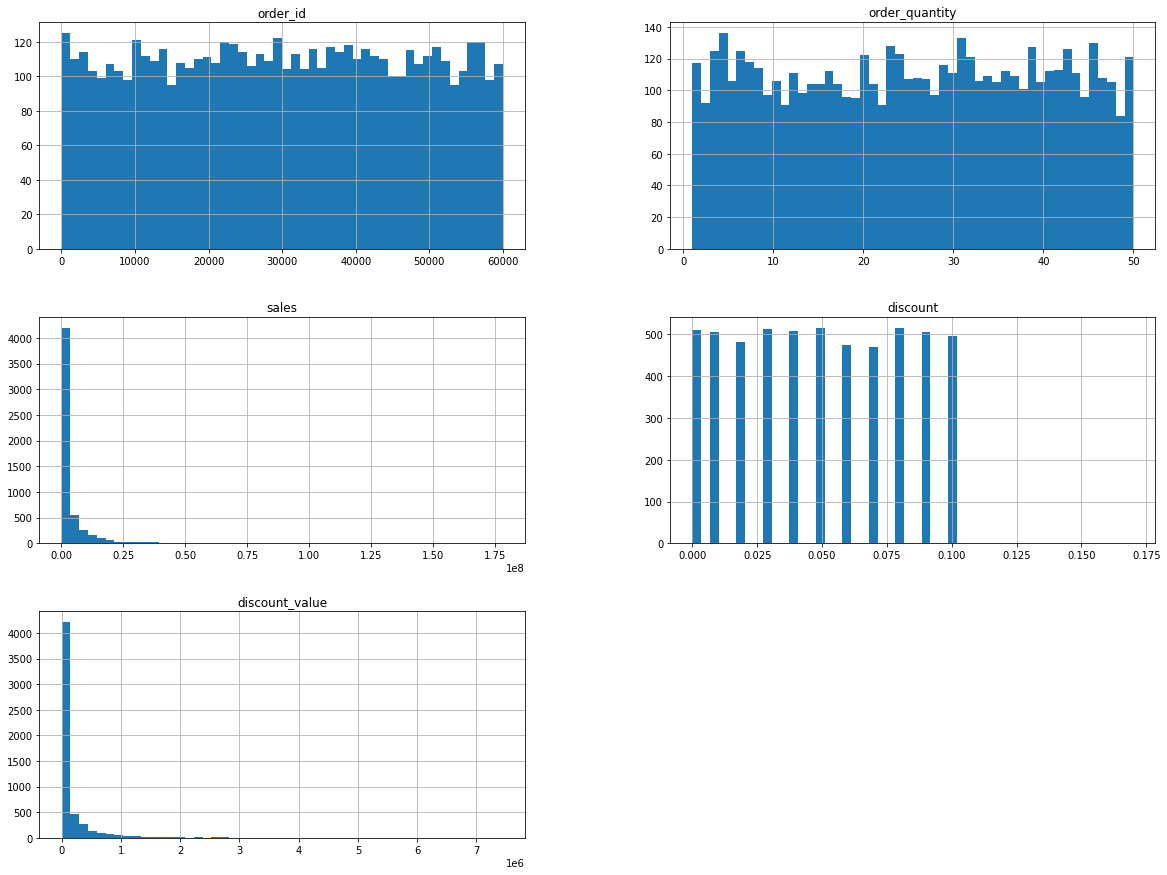

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histograms to visualize distribution of variables
df.hist(bins=50, figsize=(20,15))
plt.show()

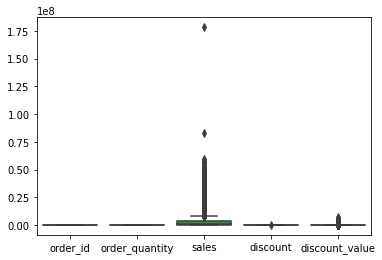

In [ ]:
# Plot box plots to identify outliers
sns.boxplot(data=df)
plt.show()

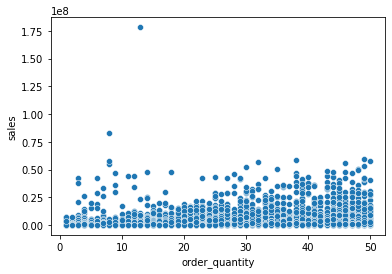

In [ ]:
# Plot scatter plots to visualize relationships between variables
sns.scatterplot(x="order_quantity", y="sales", data=df)
plt.show()

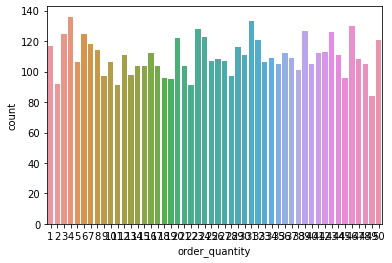

In [ ]:
# Plot bar charts to compare the distribution of categorical variables
sns.countplot(x="order_quantity", data=df)
plt.show()


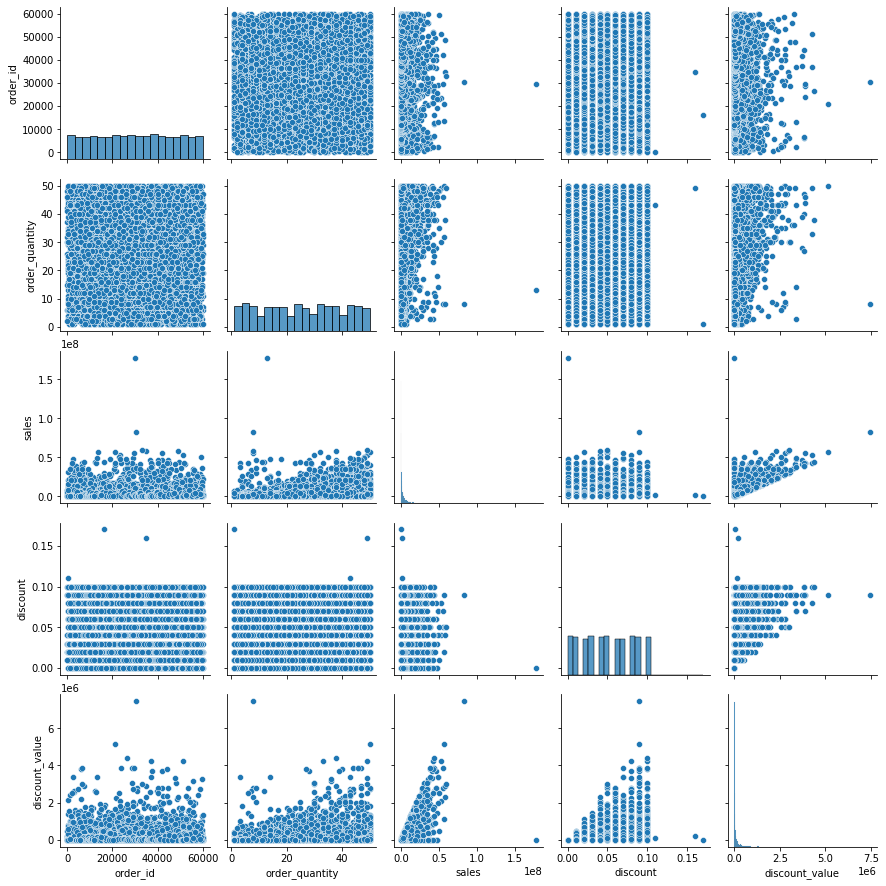

In [ ]:
# Plot pair plots to visualize relationships between all variables
sns.pairplot(df)
plt.show()

In [ ]:
# Calculate Pearson's correlation coefficient
correlation = df.corr()
print(correlation)

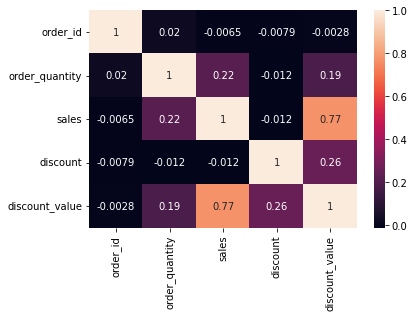

In [ ]:
# Plot a heatmap to visualize the correlation matrix
sns.heatmap(correlation, annot=True)
plt.show()


In [ ]:
# Perform chi-squared test of independence to understand the relationship between categorical variables
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df["order_quantity"], df["sales"])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("p-value:", p)

p-value: 0.2504940241589873
